In [4]:
import pandas as pd
import numpy as np

In [5]:
import os

In [6]:
import kagglehub
path = kagglehub.dataset_download("whenamancodes/students-performance-in-exams")

100%|██████████| 8.67k/8.67k [00:00<00:00, 17.3MB/s]

Extracting files...


In [7]:
file_path = os.path.join(path , 'exams.csv')


In [8]:
df = pd.read_csv(file_path)
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group A,high school,standard,completed,67,67,63
1,female,group D,some high school,free/reduced,none,40,59,55
2,male,group E,some college,free/reduced,none,59,60,50
3,male,group B,high school,standard,none,77,78,68
4,male,group E,associate's degree,standard,completed,78,73,68


In [9]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,male,group C,high school,standard,none,73,70,65
996,male,group D,associate's degree,free/reduced,completed,85,91,92
997,female,group C,some high school,free/reduced,none,32,35,41
998,female,group C,some college,standard,none,73,74,82
999,male,group A,some college,standard,completed,65,60,62


In [10]:
df.shape

(1000, 8)

In [15]:
df['test preparation course'].unique()

array(['completed', 'none'], dtype=object)

## Regression: Predict Math Score

In [16]:
x = df.drop(['math score'], axis=1)
y = df['math score']

In [17]:
x.shape

(1000, 7)

In [18]:
y.shape

(1000,)

In [19]:
x_cat = x.select_dtypes(include=object).columns
x_num = x.select_dtypes(include='number').columns

In [20]:
import sklearn
from sklearn.preprocessing import OneHotEncoder , StandardScaler

In [21]:
from sklearn.compose import ColumnTransformer

In [22]:
encoder = OneHotEncoder(handle_unknown='ignore')
scale = StandardScaler()

In [23]:
process = ColumnTransformer([
    ('cat',encoder , x_cat ),
    ('num', scale , x_num)
])

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
xtn , xt , ytn , yt = train_test_split( x , y , random_state=40)

In [26]:
x_train , x_val , y_train , y_val = train_test_split( xtn , ytn , random_state=40)

In [27]:
x_train=process.fit_transform(x_train)
xt = process.transform(xt)

In [28]:
x_val = process.transform(x_val)

### Scaling the Target Variable

Just as we scaled the input features, it's often beneficial to scale the target variable for neural networks. This helps the optimization process as the loss landscape becomes smoother, and gradients are more consistent. We'll use `StandardScaler` for the `math score`.

In [29]:
type(x_train)

numpy.ndarray

In [30]:
type(y_train)

pandas.core.series.Series

In [31]:
import torch

In [32]:
x_tensor = torch.tensor(x_train, dtype=torch.float32)

### Convert scaled validation data to PyTorch Tensors

We also need to convert our scaled `x_val` and `y_val` to PyTorch tensors so they can be used for evaluation during training.

In [33]:
y_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).unsqueeze(1)

In [34]:
y_tensor.shape

torch.Size([562, 1])

In [35]:
x_tensor.shape

torch.Size([562, 19])

In [36]:
x_val_tensor = torch.tensor(x_val , dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.to_numpy(), dtype=torch.float32).unsqueeze(1)

In [37]:
import torch.nn as nn
from torch.optim import Adam


In [38]:
class Model(nn.Module):
  def __init__(self) -> None:
    super().__init__()

    self.network = nn.Sequential(
        nn.Linear(19, 64),
        nn.ReLU(),
        nn.Linear(64,32),
        nn.LeakyReLU(),
        nn.Linear(32,1)
    )

  def forward(self , x):
    return self.network(x)

In [39]:
model = Model()
optimizer = Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

In [40]:
xt_tensor = torch.tensor(xt , dtype=torch.float32)
yt_tensor = torch.tensor(yt.to_numpy(), dtype=torch.float32).unsqueeze(1)

In [41]:
# training

train_losses = []
val_losses = []

for epoch in range(1000):

    # ---- TRAIN ----
    model.train()
    optimizer.zero_grad()

    logits = model(x_tensor)
    loss = criterion(logits, y_tensor)

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # ---- VALIDATION ----
    model.eval()
    with torch.no_grad():
        val_logits = model(x_val_tensor)
        val_loss = criterion(val_logits, y_val_tensor)

        val_losses.append(val_loss.item())
        if epoch % 20 ==0:
          print(f"Epoch {epoch}: Train Loss = {loss.item():.4f}, Val Loss = {val_loss.item():.4f}")

Epoch 0: Train Loss = 4624.4282, Val Loss = 4875.4644
Epoch 20: Train Loss = 4566.2754, Val Loss = 4812.5737
Epoch 40: Train Loss = 4420.3022, Val Loss = 4651.4702
Epoch 60: Train Loss = 4051.2900, Val Loss = 4245.2104
Epoch 80: Train Loss = 3291.0134, Val Loss = 3417.0874
Epoch 100: Train Loss = 2098.0149, Val Loss = 2136.4465
Epoch 120: Train Loss = 821.0367, Val Loss = 796.3543
Epoch 140: Train Loss = 142.0305, Val Loss = 120.2272
Epoch 160: Train Loss = 71.6922, Val Loss = 58.2756
Epoch 180: Train Loss = 62.1443, Val Loss = 48.1183
Epoch 200: Train Loss = 55.2310, Val Loss = 42.8041
Epoch 220: Train Loss = 50.3701, Val Loss = 39.1202
Epoch 240: Train Loss = 46.3897, Val Loss = 36.2278
Epoch 260: Train Loss = 43.1757, Val Loss = 34.0394
Epoch 280: Train Loss = 40.6065, Val Loss = 32.3899
Epoch 300: Train Loss = 38.5800, Val Loss = 31.1908
Epoch 320: Train Loss = 36.9950, Val Loss = 30.3643
Epoch 340: Train Loss = 35.7677, Val Loss = 29.8321
Epoch 360: Train Loss = 34.8247, Val Loss 

In [42]:
from sklearn.metrics import r2_score

In [43]:
model.eval()

with torch.no_grad():
  prediction = model(xt_tensor)
  print(r2_score(yt_tensor , prediction))


0.8661320912307438


In [44]:
for i, layer in enumerate(model.network):
    if isinstance(layer, nn.Linear):
        print(f"Layer {i}")
        print("Weights:", layer.weight)
        print("Bias:", layer.bias)
        print()

Layer 0
Weights: Parameter containing:
tensor([[-0.1362,  0.0288, -0.1472,  ...,  0.1358,  0.1397,  0.0821],
        [-0.0728,  0.1861,  0.1477,  ...,  0.1858,  0.2631,  0.0778],
        [-0.0394,  0.4483,  0.3146,  ...,  0.1641, -0.2613, -0.2527],
        ...,
        [ 0.0900,  0.1071,  0.3058,  ...,  0.3843,  0.1361,  0.3801],
        [-0.1216,  0.3657,  0.1437,  ...,  0.3780, -0.3164, -0.0190],
        [ 0.0464,  0.3610, -0.0883,  ...,  0.2273,  0.2320,  0.1954]],
       requires_grad=True)
Bias: Parameter containing:
tensor([ 0.1171,  0.2922,  0.0123,  0.3740,  0.3052,  0.0405,  0.1258,  0.0815,
         0.1672,  0.2357,  0.2085,  0.1050,  0.2487, -0.0091,  0.0363,  0.2901,
         0.2359,  0.2096,  0.1445,  0.2760,  0.2612,  0.3536,  0.1847,  0.2517,
         0.3444,  0.3255,  0.1305,  0.1013,  0.0691,  0.0696,  0.3751,  0.0241,
         0.1280, -0.0048,  0.0010,  0.2955,  0.1953,  0.2298,  0.2166,  0.1605,
         0.1415,  0.3185,  0.2313,  0.3508,  0.0410,  0.1271,  0.2097,  

In [45]:
weights = model.network[0].weight.detach()

# importance per input feature
importance = weights.abs().mean(dim=0)

print(importance)

tensor([0.1438, 0.2784, 0.1879, 0.1770, 0.1704, 0.1609, 0.2465, 0.1902, 0.1911,
        0.1928, 0.1916, 0.1951, 0.1941, 0.1664, 0.2330, 0.1654, 0.2196, 0.1736,
        0.1974])


In [46]:
x = torch.randn(1, 19)

for i, layer in enumerate(model.network):
    x = layer(x)
    print(f"After layer {i}: {x}")

After layer 0: tensor([[-1.3521, -0.9252,  0.8952,  1.1125, -1.0782, -0.5683, -0.9426, -0.4979,
         -0.3563, -0.1122, -0.2111, -0.5843, -0.2723,  1.0796, -1.7005, -0.3646,
          0.7629, -0.0230, -0.6058, -0.2699, -0.6940, -0.8626, -0.0834,  0.6574,
          0.8587, -0.0307,  0.7084, -0.0133,  1.2865, -0.5449, -0.2308, -0.0299,
          0.1690,  1.0235, -0.8220, -0.2616, -0.4174,  0.5002,  0.0297,  0.5455,
         -0.2833,  0.1329, -0.9594,  0.2733,  0.5552,  0.7177,  0.2497, -0.6551,
          1.5458, -1.3843, -0.3079, -1.2254, -0.2948, -0.3989, -0.2102,  0.6373,
          0.5269,  0.1763, -0.8006,  1.3930, -0.4687,  0.6573,  1.5739, -0.7766]],
       grad_fn=<AddmmBackward0>)
After layer 1: tensor([[0.0000, 0.0000, 0.8952, 1.1125, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 1.0796, 0.0000, 0.0000, 0.7629, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.6574, 0.8587, 0.0000, 0.7084,
         0.0000, 1.2865, 0.0000, 0.0000, 0.0

In [47]:
def hook_fn(module, input, output):
    print(module, output)

for layer in model.network:
    layer.register_forward_hook(hook_fn)

In [48]:
x = torch.linspace(0, 100, 100).unsqueeze(1)
y = model(x).detach()

plt.scatter(X_train, y_train)
plt.plot(x, y)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (100x1 and 19x64)

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# assume X has 2 features
x_min, x_max = x[:,0].min(), x[:,0].max()
y_min, y_max = x[:,].min(), x[:,].max()

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()]).float()

with torch.no_grad():
    preds = model(grid).reshape(xx.shape)

plt.contourf(xx, yy, preds)
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

RuntimeError: mat1 and mat2 shapes cannot be multiplied (10000x2 and 19x64)

In [51]:
x = torch.zeros(100, 19)

# vary only feature 0
x[:, 0] = torch.linspace(0, 1, 100)

y = model(x).detach()

Linear(in_features=19, out_features=64, bias=True) tensor([[ 0.1171,  0.2922,  0.0123,  ...,  0.1853,  0.1475,  0.0763],
        [ 0.1157,  0.2915,  0.0119,  ...,  0.1862,  0.1462,  0.0768],
        [ 0.1143,  0.2907,  0.0116,  ...,  0.1871,  0.1450,  0.0773],
        ...,
        [-0.0164,  0.2208, -0.0262,  ...,  0.2735,  0.0283,  0.1218],
        [-0.0178,  0.2201, -0.0266,  ...,  0.2744,  0.0271,  0.1222],
        [-0.0192,  0.2194, -0.0270,  ...,  0.2753,  0.0258,  0.1227]],
       grad_fn=<AddmmBackward0>)
ReLU() tensor([[0.1171, 0.2922, 0.0123,  ..., 0.1853, 0.1475, 0.0763],
        [0.1157, 0.2915, 0.0119,  ..., 0.1862, 0.1462, 0.0768],
        [0.1143, 0.2907, 0.0116,  ..., 0.1871, 0.1450, 0.0773],
        ...,
        [0.0000, 0.2208, 0.0000,  ..., 0.2735, 0.0283, 0.1218],
        [0.0000, 0.2201, 0.0000,  ..., 0.2744, 0.0271, 0.1222],
        [0.0000, 0.2194, 0.0000,  ..., 0.2753, 0.0258, 0.1227]],
       grad_fn=<ReluBackward0>)
Linear(in_features=64, out_features=32, bias=

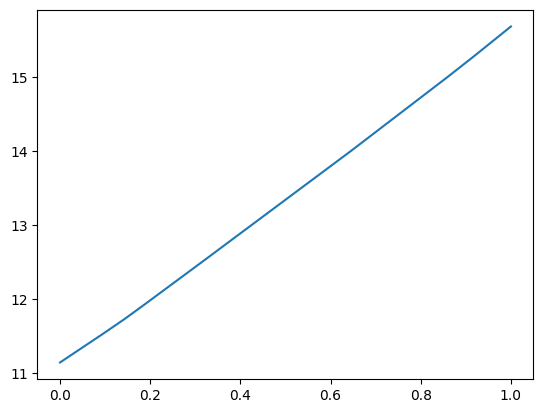

In [52]:
plt.plot(x[:,0], y)